In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll

plt.rcParams["font.family"] = "monospace"

_ROOT = Path.cwd().parent
_CORE = _ROOT / "core"
_DATA = _ROOT / "data"
EXPERT = _DATA / "expert.npz"

print(f"NumPy Version: {np.__version__}")

NumPy Version: 2.4.4


In [2]:
print(f"Data Path: {EXPERT}")
dExpert = np.load(EXPERT)

print("Expert Data Keys:", dExpert.files)

Data Path: /home/abhans/Projects/acraft/data/expert.npz
Expert Data Keys: ['trajectories']


# Expert Data
Expert data consists of data in shape `(Number of waypoints, Steps per waypoint, The state and action vector for each step)`

In [3]:
print(f"Shape of the expert data: {dExpert["trajectories"].shape}")

Shape of the expert data: (2000, 1000, 10)


In [4]:
numOfTraj, stepsPerTraj, params = dExpert["trajectories"].shape

print(
    f"Number of Trajectories: {numOfTraj}",
    f"Steps per Trajectory: {stepsPerTraj}",
    f"Parameters per Step: {params}",
    sep="\n",
)

Number of Trajectories: 2000
Steps per Trajectory: 1000
Parameters per Step: 10


# Plotting the Parameters

For a single chosen trajectory, we can plot the action and state vectors

In [5]:
trajIdx = np.random.randint(numOfTraj)
traj = dExpert["trajectories"][trajIdx]

timeSteps = np.arange(stepsPerTraj)
print(f"Data from trajectory: {trajIdx}")

Data from trajectory: 1579


In [6]:
# Name the parameters
#  state = np.array([x, y, vx, vy, theta, omega, windX, windY], dtype=np.float32)
#  action = np.array([lThrust, rThrust], dtype=np.float32)
x, y, vx, vy, theta, omega, windX, windY = traj[:, :8].T
lThrust, rThrust = traj[:, 8:].T

print(f"Actions | RThrust: {rThrust}, LThrust: {lThrust}")

# Compute wind magnitude
windMag = np.hypot(windX, windY)

Actions | RThrust: [0.64963263 0.64072686 0.6475353  0.650073   0.6476694  0.65127206
 0.6394451  0.64571023 0.6504559  0.6345036  0.6479229  0.6482455
 0.64402443 0.6371389  0.65570134 0.6339197  0.63423944 0.61498016
 0.6033023  0.6121299  0.5930553  0.58156204 0.56437474 0.576039
 0.5657442  0.54613495 0.54711455 0.5226115  0.52947277 0.5136935
 0.5061694  0.50968033 0.5030406  0.49923027 0.49502602 0.48189247
 0.490684   0.47748658 0.4741948  0.46540487 0.45660427 0.46600124
 0.4599304  0.45171034 0.45344165 0.45224008 0.45641875 0.45027354
 0.44767565 0.44005942 0.439581   0.43907487 0.43469667 0.43702292
 0.4501785  0.43374723 0.4443048  0.44451135 0.44698375 0.4436426
 0.44562188 0.44427365 0.44016594 0.44209623 0.4423982  0.4474499
 0.4427911  0.45361948 0.4506384  0.4349942  0.45012596 0.44356048
 0.43434262 0.44145602 0.43967548 0.44537675 0.4435361  0.4465283
 0.43756407 0.43297645 0.44360182 0.43439215 0.42955235 0.43245164
 0.43120384 0.4234573  0.42550296 0.42532575 0.431

In [7]:
NAVY: str    = "#182C4E"
OCHRE: str   = "#BBA358"

SEAFOAM: str = "#245C69"
OLIVE: str   = "#77844E"
# Wind Visualization
SAGE: str    = "#4E7D5D"

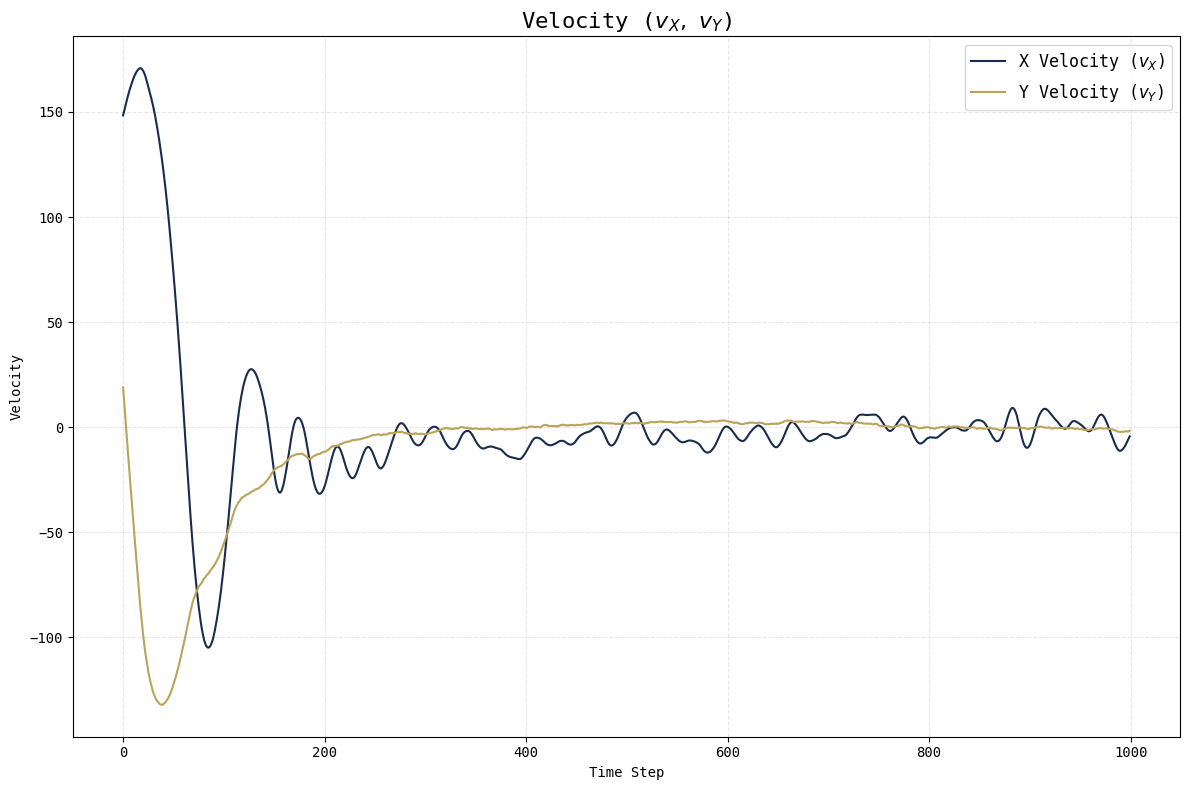

In [8]:
plt.figure(figsize=(12, 8))
# ------------ Velocity Plot ------------ 
plt.plot(timeSteps, vx, label=r"X Velocity ($v_X$)", color=NAVY)
plt.plot(timeSteps, vy, label=r"Y Velocity ($v_Y$)", color=OCHRE)
plt.title(r"Velocity ($v_X,\ v_Y$)", fontsize=16)
plt.xlabel("Time Step")
plt.ylabel("Velocity")
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

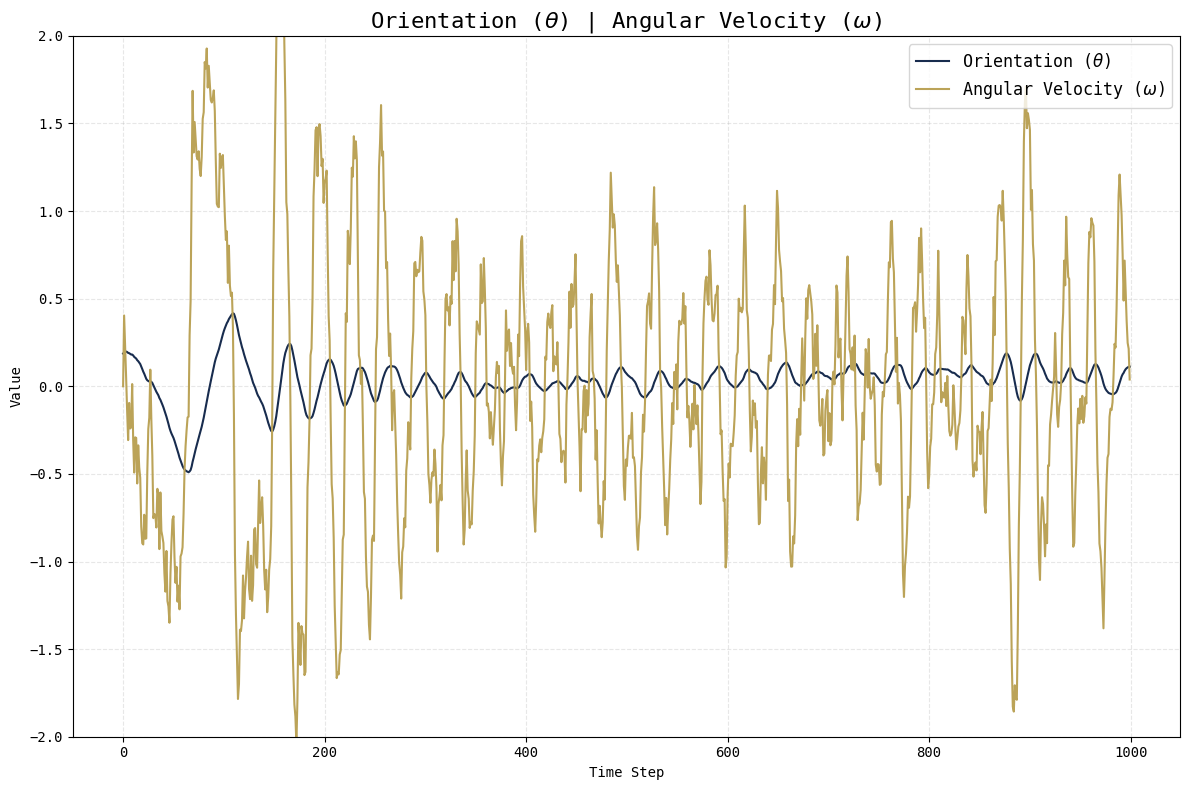

In [9]:
plt.figure(figsize=(12, 8))
# ------------ Orientation & Angular Velocity Plot ------------
plt.plot(timeSteps, theta, label=r"Orientation ($\theta$)", color=NAVY)
plt.plot(timeSteps, omega, label=r"Angular Velocity ($\omega$)", color=OCHRE)
plt.title(r"Orientation ($\theta$) | Angular Velocity ($\omega$)", fontsize=16)
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.ylim(-2, 2)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

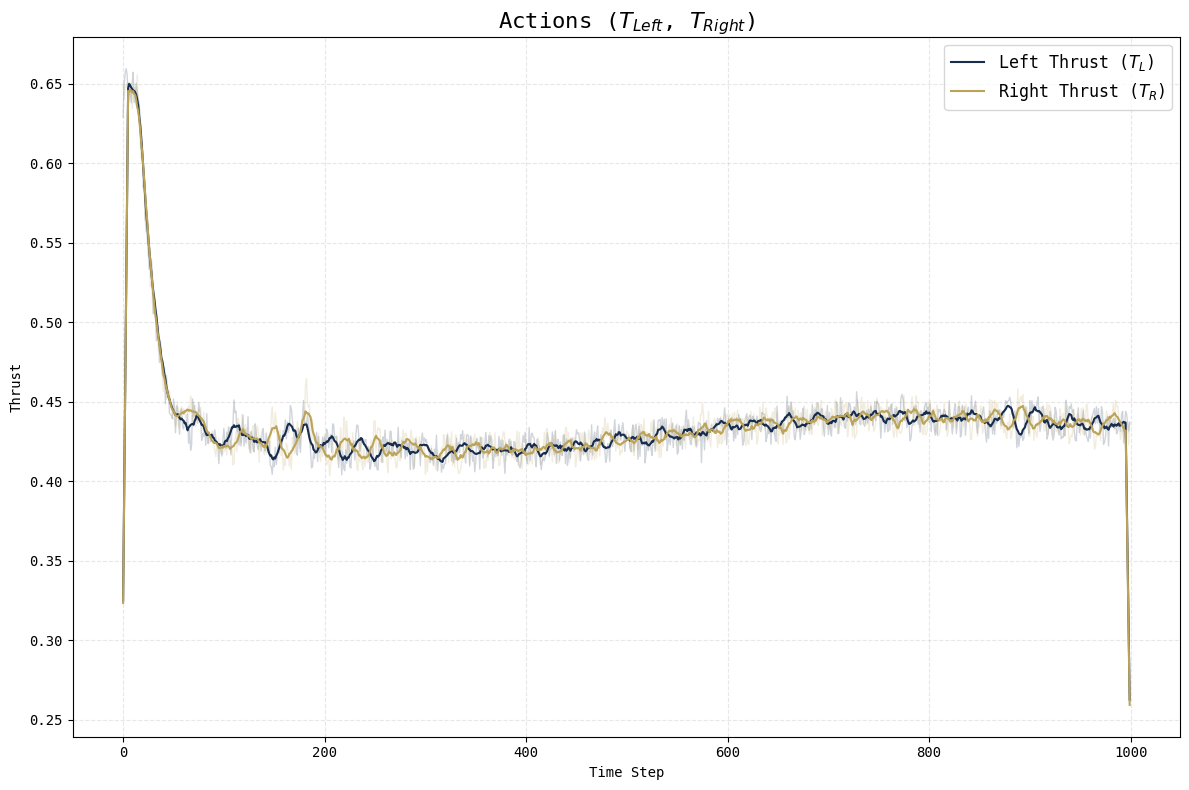

In [10]:
plt.figure(figsize=(12, 8))
sWindow: int = 10
kernel: np.ndarray = np.ones(sWindow) / sWindow
# ------------ Actions (Thrust) Plot ------------
plt.plot(timeSteps, lThrust, alpha=0.2, linewidth=1, color=NAVY)
plt.plot(timeSteps, rThrust, alpha=0.2, linewidth=1, color=OCHRE)

plt.plot(
    timeSteps,
    np.convolve(lThrust, kernel, mode="same"),
    label=r"Left Thrust ($T_{L}$)", linewidth=1.5, color=NAVY
)
plt.plot(
    timeSteps,
    np.convolve(rThrust, kernel, mode="same"),
    label=r"Right Thrust ($T_{R}$)", linewidth=1.5, color=OCHRE
)

plt.title(r"Actions ($T_{Left}$, $T_{Right}$)", fontsize=16)
plt.xlabel("Time Step")
plt.ylabel("Thrust")
plt.legend(loc="upper right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Animating the Parameters

It would be a great practice to visualize the trajectory and the parameters in real-time

In [11]:
import numpy as np
import math
import warnings
from dataclasses import dataclass

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Embedding videos in Jupyter Notebooks
from IPython.display import Video

mpl.rcParams['animation.embed_limit'] = 100.0
warnings.filterwarnings("ignore", category=UserWarning)

@dataclass
class Screen:
    WIDTH: int = 1200
    HEIGHT: int = 800
    MARGIN: int = 20

trajIdx = np.random.randint(numOfTraj)
traj = dExpert["trajectories"][trajIdx]

X = traj[:, 0]
Y = traj[:, 1]

numFrames = len(X)
segColors = np.linspace(0, numFrames - 1, numFrames - 1)
norm = plt.Normalize(vmin=0, vmax=numFrames - 1)

In [12]:
# Drone Visualization
lARM: int = 30
sTHRUST: float = .5

def _thrustColors(thrust):
    """Maps thrust [0, 1] to the Managua spectrum."""
    thrust = np.clip(thrust, 0, 1)
    return plt.cm.managua(thrust)

Saving Frame 1000 :: 1000
Animation 'exTrajDrone[598].mp4' saved successfully!


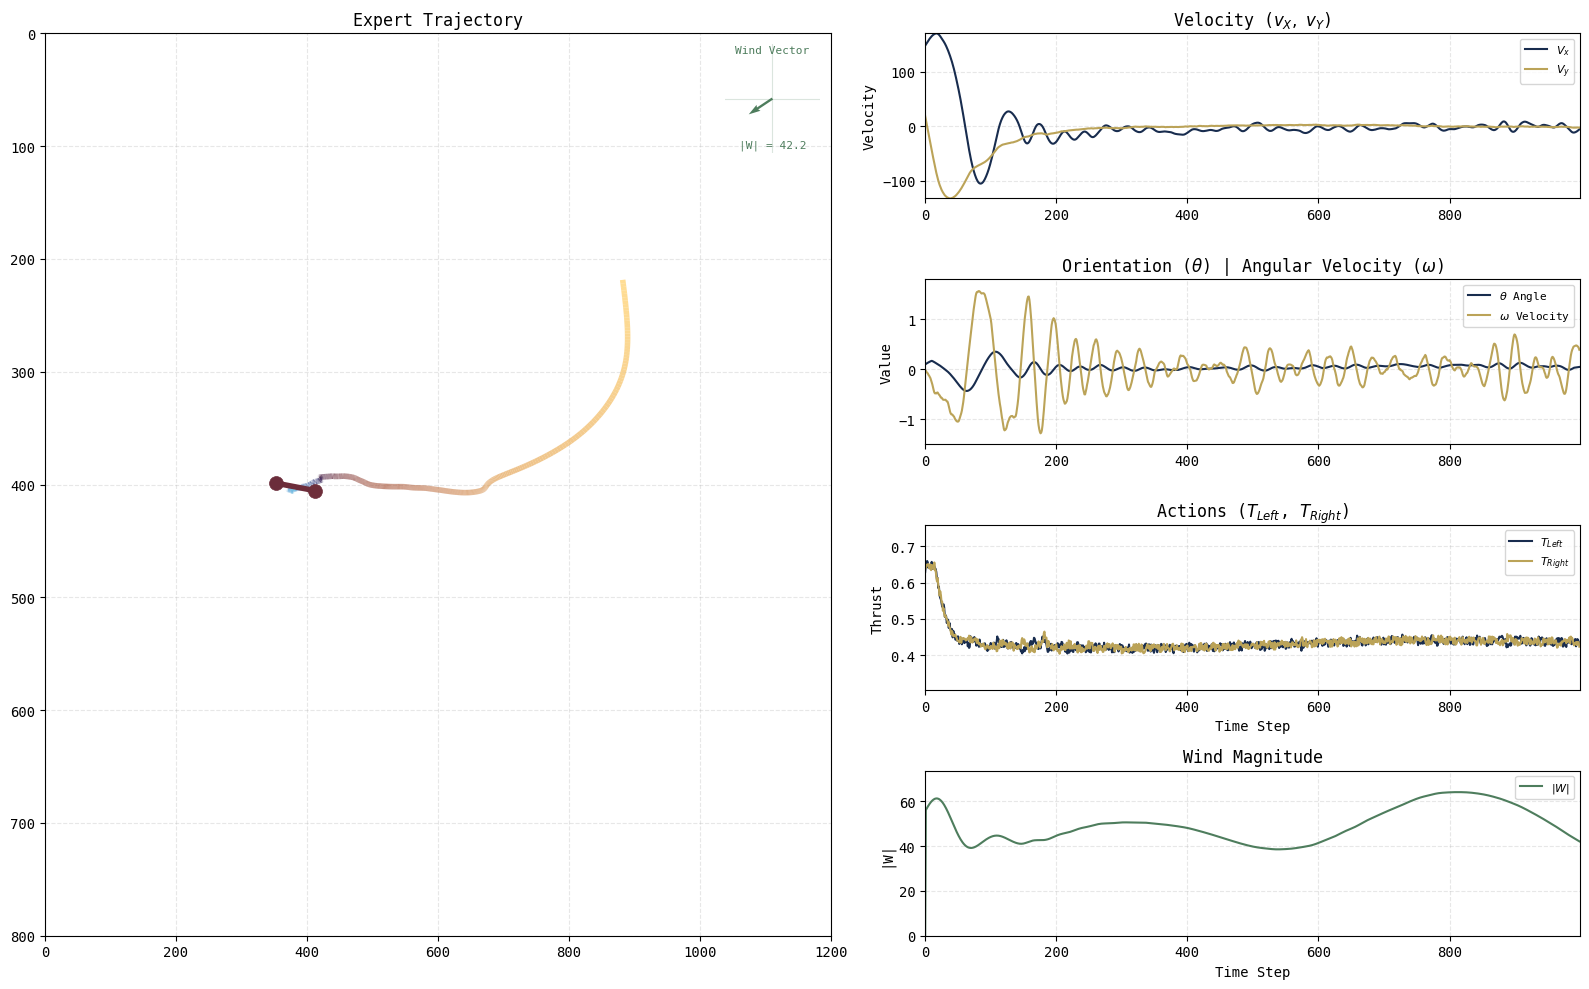

In [13]:
# ------------------------------------------------ Setup Figure and Grid ------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(4, 2, width_ratios=[1.2, 1])
# Smoothing
sWindow: int = 20
kernel: np.ndarray = np.ones(sWindow) / sWindow

# Pre-smoothing theta and omega
smoothedTheta = np.convolve(theta, kernel, mode='same')
smoothedOmega = np.convolve(omega, kernel, mode='same')

# Left: Trajectory Plot
axTraj = fig.add_subplot(gs[:, 0])
axTraj.set_title("Expert Trajectory")
axTraj.set_xlim(0, Screen.WIDTH)
axTraj.set_ylim(Screen.HEIGHT, 0)
axTraj.grid(True, linestyle='--', alpha=0.3, zorder=0)

# ------------------------------------------------ Wind HUD ------------------------------------------------
axWindHUD = inset_axes(
    axTraj,
    width="12%",
    height="12%",
    loc="upper right",
    borderpad=0.8
)

axWindHUD.set_facecolor((0, 0, 0, 0.0))

windLimit = max(
    np.max(np.abs(windX)),
    np.max(np.abs(windY))
) * 1.15

axWindHUD.set_xlim(-windLimit, windLimit)
axWindHUD.set_ylim(-windLimit, windLimit)

# Crosshair
axWindHUD.axhline(0, color=SAGE, lw=0.8, alpha=0.2)
axWindHUD.axvline(0, color=SAGE, lw=0.8, alpha=0.2)

# Remove clutter
axWindHUD.set_xticks([])
axWindHUD.set_yticks([])
axWindHUD.set_title("Wind Vector", fontsize=8, color=SAGE, y=0.92, va="top")

for spine in axWindHUD.spines.values():
    spine.set_color(SAGE)
    spine.set_alpha(0.)

# Single dynamic wind vector
windArrow = axWindHUD.quiver(
    [0],
    [0],
    [0],
    [0],
    angles='xy',
    scale_units='xy',
    scale=1,
    color=SAGE,
    width=0.025,
    zorder=5
)

# Wind magnitude label
windText = axWindHUD.text(
    0.5,
    0.05,
    "",
    transform=axWindHUD.transAxes,
    fontsize=8,
    color=SAGE,
    ha='center'
)

# Right: Parameter Subplots
axVel = fig.add_subplot(gs[0, 1])
axOrient = fig.add_subplot(gs[1, 1])
axThr = fig.add_subplot(gs[2, 1])

for ax in [axVel, axOrient, axThr]:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlim(timeSteps[0], timeSteps[-1])

# ---- PLOTS: Parameters ----
axVel.set_title(r"Velocity ($v_X,\ v_Y$)")
axVel.set_ylabel("Velocity")
axVel.grid(True, linestyle='--', alpha=0.3)
axVel.set_xlim(timeSteps[0], timeSteps[-1])
axVel.set_ylim(min(np.min(vx), np.min(vy)) - 0.1, max(np.max(vx), np.max(vy)) + 0.1)

axOrient.set_title(r"Orientation ($\theta$) | Angular Velocity ($\omega$)")
axOrient.set_ylabel("Value")
axOrient.grid(True, linestyle='--', alpha=0.3)
axOrient.set_xlim(timeSteps[0], timeSteps[-1])
axOrient.set_ylim(-1.5, 1.8)

axThr.set_title(r"Actions ($T_{Left}$, $T_{Right}$)")
axThr.set_xlabel("Time Step")
axThr.set_ylabel("Thrust")
axThr.grid(True, linestyle='--', alpha=0.3)
axThr.set_xlim(timeSteps[0], timeSteps[-1])
axThr.set_ylim(min(np.min(lThrust), np.min(rThrust)) - 0.1, max(np.max(lThrust), np.max(rThrust)) + 0.1)

axWind = fig.add_subplot(gs[3, 1])
axWind.set_title("Wind Magnitude")
axWind.set_xlabel("Time Step")
axWind.set_ylabel("|W|")
axWind.set_ylim(0, np.max(windMag) * 1.15)
axWind.set_xlim(timeSteps[0], timeSteps[-1])
axWind.grid(True, linestyle='--', alpha=0.3)

# ------------------------------------------------ Initialize Artists ------------------------------------------------
lc = mcoll.LineCollection([], cmap='managua', norm=norm, alpha=0.7, linewidth=4)
axTraj.add_collection(lc)
scatter = axTraj.scatter([], [], c=[], cmap='managua', norm=norm, s=0, zorder=5)
# Add wind quiver (arrows)
sampleStep = 12
maxArrows = len(np.arange(0, numFrames, sampleStep))

# Body Frame
droneFrame, = axTraj.plot([], [], color=SEAFOAM, lw=4, solid_capstyle='round', zorder=10)

# Visualizing Rotors
lRotor, = axTraj.plot([], [], 'o', markersize=10, markeredgecolor='white', markeredgewidth=0.5, zorder=11)
rRotor, = axTraj.plot([], [], 'o', markersize=10, markeredgecolor='white', markeredgewidth=0.5, zorder=11)

# Parameter Lines
lineVx, = axVel.plot([], [], color=NAVY, label=r"$V_x$", linewidth=1.5)
lineVy, = axVel.plot([], [], color=OCHRE, label=r"$V_y$", linewidth=1.5)
lineTheta, = axOrient.plot([], [], color=NAVY, label=r"$\theta$ Angle", linewidth=1.5)
lineOmega, = axOrient.plot([], [], color=OCHRE, label=r"$\omega$ Velocity", linewidth=1.5)
lineLeftThr, = axThr.plot([], [], color=NAVY, label=r"$T_{Left}$", linewidth=1.5)
lineRightThr, = axThr.plot([], [], color=OCHRE, label=r"$T_{Right}$", linewidth=1.5)
lineWindMag, = axWind.plot([], [], color=SAGE, label=r"$|W|$")

axVel.legend(loc="upper right", framealpha=0.8, fontsize=8)
axOrient.legend(loc="upper right", framealpha=0.8, fontsize=8)
axThr.legend(loc="upper right", framealpha=0.8, fontsize=8)
axWind.legend(loc="upper right", framealpha=0.8, fontsize=8)

def update(frame):
    if frame < 2:
        return lc, scatter, droneFrame, lRotor, rRotor, lineVx, lineVy, lineTheta, lineOmega, lineLeftThr, lineRightThr

    # Update Trajectory Path
    points = np.array([X[:frame], Y[:frame]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc.set_segments(segments)
    lc.set_array(segColors[:frame-1])
    
    currWindX = windX[frame - 1]
    currWindY = windY[frame - 1]

    windArrow.set_UVC(
        [currWindX],
        [currWindY]
    )

    currWindMag = np.hypot(currWindX, currWindY)

    windText.set_text(
        f"|W| = {currWindMag:.1f}"
    )

    # Decimated Scatter Trail
    maskStep = np.arange(0, frame, 10)
    if len(maskStep) > 0:
        scatter.set_offsets(np.c_[X[maskStep], Y[maskStep]])
        scatter.set_array(maskStep)

# ------------------------------------------------ Drone Rendering ------------------------------------------------
    currX, currY = X[frame-1], Y[frame-1]
    currTheta = theta[frame-1]
    
    dx = lARM * math.cos(currTheta)
    dy = lARM * math.sin(currTheta)
    
    lx, ly = currX - dx, currY - dy
    rx, ry = currX + dx, currY + dy
    
    # Update Body
    droneFrame.set_data([lx, rx], [ly, ry])
    
    # Update Rotor Dots (Positions)
    lRotor.set_data([lx], [ly])
    rRotor.set_data([rx], [ry])
    
    # Update Rotor Colors (Thrust Intensity)
    lAction, rAction = lThrust[frame-1], rThrust[frame-1]
    lRotor.set_markerfacecolor(_thrustColors(lAction))
    lRotor.set_markeredgecolor(_thrustColors(lAction))

    rRotor.set_markerfacecolor(_thrustColors(rAction))
    rRotor.set_markeredgecolor(_thrustColors(rAction))

    droneFrame.set_color(_thrustColors((lAction + rAction) / 2))

    # Update Parameter Plots
    lineVx.set_data(timeSteps[:frame], vx[:frame])
    lineVy.set_data(timeSteps[:frame], vy[:frame])
    lineTheta.set_data(timeSteps[:frame], smoothedTheta[:frame])
    lineOmega.set_data(timeSteps[:frame], smoothedOmega[:frame])
    lineLeftThr.set_data(timeSteps[:frame], lThrust[:frame])
    lineRightThr.set_data(timeSteps[:frame], rThrust[:frame])
    lineWindMag.set_data(
        timeSteps[:frame],
        windMag[:frame]
    )

    return (lc, scatter, droneFrame, lRotor, rRotor, 
            lineVx, lineVy, lineTheta, lineOmega, 
            lineLeftThr, lineRightThr, 
            lineWindMag, 
            windArrow, windText)

# ------------------------------------------------ Generate and Save ------------------------------------------------
plt.tight_layout()

anim = animation.FuncAnimation(fig, update, frames=numFrames, interval=15, blit=True)
anim.save(f'exTrajDrone[{trajIdx}].mp4', writer='ffmpeg', fps=60, progress_callback=lambda i, n: print(f"Saving Frame {i + 1} :: {n}", end='\r'))
print(f"\nAnimation 'exTrajDrone[{trajIdx}].mp4' saved successfully!")

In [14]:
Video(f"exTrajDrone[{trajIdx}].mp4", embed=True)